# Практическая работа №3
## Оптимизация одноканальной системы с ограниченной очередью (M/M/1/m)

**Цель работы:**
Исследовать характеристики системы M/M/1/m, определить оптимальную длину очереди, обеспечивающую вероятность потери заявок не выше заданного порога (5%), и проанализировать влияние параметров на эффективность системы.

**Задачи:**
1. Построить математическую модель M/M/1/m.
2. Рассчитать основные показатели эффективности.
3. Провести имитационное моделирование и сравнить с теорией.
4. Найти оптимальное значение $m$, при котором $P_{\text{loss}} \le 0.05$.
5. Проанализировать зависимость вероятности потерь и времени ожидания от длины очереди.

**Исходные данные:**
- $\lambda = 8$ заявок/час
- $\mu = 10$ заявок/час
- $m \in \{1, ..., 16\}$
- Порог $P_{\text{loss}} \le 5\%$

## 1. Теоретическая модель M/M/1/m

### 1.1. Определение и допущения
Система M/M/1/m представляет собой одноканальную СМО с ограниченной очередью.
- Входящий поток — пуассоновский с интенсивностью $\lambda$.
- Время обслуживания распределено экспоненциально с параметром $\mu$.
- В системе один обслуживающий канал.
- Максимальное число заявок в очереди — $m$.
- Общее число мест в системе $K = m + 1$ (один обслуживается, $m$ ждут).
- Если заявка застаёт систему полностью заполненной ($K$ заявок), она **теряется**.

В отличие от системы с бесконечной очередью, стационарный режим существует при любых $\lambda$ и $\mu$ благодаря конечному числу состояний.

### 1.2. Марковский процесс и вероятности состояний
Состояние $k \in \{0, 1, \dots, K\}$ — число заявок в системе.
Интенсивности переходов:
- $\lambda_k = \lambda$ при $k < K$, иначе $0$.
- $\mu_k = \mu$ при $k \ge 1$.

Из уравнений локального баланса $\lambda P_k = \mu P_{k+1}$ следует:

$$ P_k = \rho^k P_0, \quad \rho = \frac{\lambda}{\mu}. $$

Вероятность простоя $P_0$ находится из условия нормировки:

$$ P_0 = \begin{cases}
\dfrac{1 - \rho}{1 - \rho^{K+1}}, & \rho \ne 1, \\[1em]
\dfrac{1}{K+1}, & \rho = 1.
\end{cases} $$

## 2. Расчётные формулы для характеристик системы

### 2.1. Вероятность потери заявки
Заявка теряется, если в момент её прихода все $K$ мест в системе заняты, то есть система находится в состоянии $K$. Тогда вероятность потери совпадает со стационарной вероятностью $P_K$:

$$ P_{\text{loss}} = P_K = \rho^K P_0$$

где $P_0$ – вероятность полного простоя системы, вычисляемая по формуле в части 1.2

### 2.2. Среднее число заявок в системе
Среднее число заявок, одновременно находящихся в системе (и в очереди, и на обслуживании), равно математическому ожиданию числа заявок в состояниях $0, 1, \dots, K$:

$$ L = \sum_{k=0}^K k P_k$$

Для $\rho \ne 1$ эта сумма вычисляется как:

$$ L = \frac{\rho}{1 - \rho} - \frac{(K + 1)\rho^{K + 1}}{1 - \rho^{K + 1}}$$

При $\rho = 1$ (особый случай) все состояния равновероятны, и $L = K / 2$.

### 2.3. Среднее число заявок в очереди
Заявки в очереди находятся только тогда, когда в системе более одной заявки (канал занят). Средняя длина очереди связана с $L$ и $P_0$ следующим образом:

$$ L_q = L - (1 - P_0)$$

Здесь $1 - P_0$ — вероятность того, что канал занят, то есть среднее число заявок, находящихся на обслуживании.

### 2.4. Эффективная интенсивность прибытия
Поскольку часть заявок теряется, реальная интенсивность потока, попадающего в систему, меньше номинальной $\lambda$. Она определяется как

$$ \lambda_{\text{eff}} = \lambda \cdot (1 - P_{\text{loss}})$$

### 2.5. Среднее время пребывания в системе
По закону Литтла для всей системы ($L = \lambda_{\text{eff}} \cdot W$) получаем среднее время, которое принятая заявка проводит в системе от момента прибытия до момента ухода:

$$ W = \frac{L}{\lambda_{\text{eff}}}$$

### 2.6. Среднее время ожидания в очереди
Аналогично, применяя закон Литтла к очереди ($L_q = \lambda_{\text{eff}} \cdot W_q$), находим среднее время ожидания для принятых заявок:

$$ W_q = \frac{L_q}{\lambda_{\text{eff}}}$$

### 2.7. Эффективный коэффициент загрузки канала
Долю времени, в течение которого единственный канал занят обслуживанием, можно выразить через эффективную интенсивность прибытия:

$$ \rho_{\text{eff}} = \frac{\lambda_{\text{eff}}}{\mu} = 1 - P_0$$

Этот показатель всегда меньше номинальной загрузки $\rho = \lambda / \mu$ из-за потерь части заявок.

In [13]:
import random

class Stats:
    def __init__(self):
        self.arrived = 0
        self.served = 0
        self.lost = 0

        self.total_wait_time = 0.0
        self.total_system_time = 0.0
        self.busy_time = 0.0

        self.waited = 0
        self.waiting_times = []
        self.system_times = []

        self.queue_area = 0.0
        self.last_event_time = 0.0

def update_queue_area(stats, env, queue_length):
    dt = env.now - stats.last_event_time
    stats.queue_area += queue_length * dt
    stats.last_event_time = env.now

class Object:
    def handle_time(self):
        return 0

class Patient(Object):
    pass

class Worker:
    def __init__(self, env, stats, channels=1):
        self.env = env
        self.stats = stats
        self.channels = channels
        self.resource = simpy.Resource(env, capacity=channels)

    def work(self, target):
        raise NotImplementedError

class Doctor(Worker):
    def __init__(self, env, stats, mu_rate, channels=1):
        super().__init__(env, stats, channels=channels)
        self.mu_rate = mu_rate

    def work(self, target):
        arrive_time = self.env.now

        queue_len = len(self.resource.queue)
        update_queue_area(self.stats, self.env, queue_len)

        if self.resource.count >= self.resource.capacity:
            self.stats.waited += 1

        with self.resource.request() as req:
            yield req

            queue_len = len(self.resource.queue)
            update_queue_area(self.stats, self.env, queue_len)

            wait_time = self.env.now - arrive_time
            self.stats.total_wait_time += wait_time
            if wait_time > 0:
                self.stats.waiting_times.append(wait_time)

            start_service = self.env.now
            service_time = random.expovariate(self.mu_rate) + target.handle_time()
            yield self.env.timeout(service_time)

            busy = self.env.now - start_service
            self.stats.busy_time += busy

            system_time = self.env.now - arrive_time
            self.stats.total_system_time += system_time
            self.stats.system_times.append(system_time)

            self.stats.served += 1

class PatientStreamGenerator:
    def __init__(self, env, stats, worker, lambda_rate, max_system_size):
        self.env = env
        self.stats = stats
        self.worker = worker
        self.lambda_rate = lambda_rate
        self.max_system_size = max_system_size

    def start(self):
        while True:
            next_arrival_time = random.expovariate(self.lambda_rate)
            yield self.env.timeout(next_arrival_time)

            queue_len = len(self.worker.resource.queue)
            update_queue_area(self.stats, self.env, queue_len)

            self.stats.arrived += 1

            system_size = self.worker.resource.count + queue_len
            if system_size < self.max_system_size:
                self.env.process(self.worker.work(Patient()))
            else:
                self.stats.lost += 1

Анализ системы M/M/1/m
λ = 8.0 заявок/час, μ = 10.0 заявок/час
Базовое m = 5

Базовый вариант (m=5)
Теоретическая вероятность потери: 0.0663
Экспериментальная вероятность потери: 0.0638
Среднее время ожидания (теор.): 0.1868 час
Среднее число заявок в очереди (теор.): 1.3955
Коэффициент загрузки (теор.): 0.7469

  m | P_loss теор | P_loss эксп |  Wq теор |  Wq эксп
----------------------------------------------------------------------
  0 |      0.4444 |      0.4468 |  -0.0000 |   0.0000
  1 |      0.2623 |      0.2600 |   0.0444 |   0.0442
  2 |      0.1734 |      0.1727 |   0.0852 |   0.0846
  3 |      0.1218 |      0.1219 |   0.1225 |   0.1211
  4 |      0.0888 |      0.0856 |   0.1563 |   0.1531
  5 |      0.0663 |      0.0638 |   0.1868 |   0.1827
  6 |      0.0504 |      0.0496 |   0.2142 |   0.2093
  7 |      0.0388 |      0.0369 |   0.2387 |   0.2302
  8 |      0.0301 |      0.0303 |   0.2605 |   0.2559
  9 |      0.0235 |      0.0229 |   0.2797 |   0.2721
 10 |      0.0184 |  

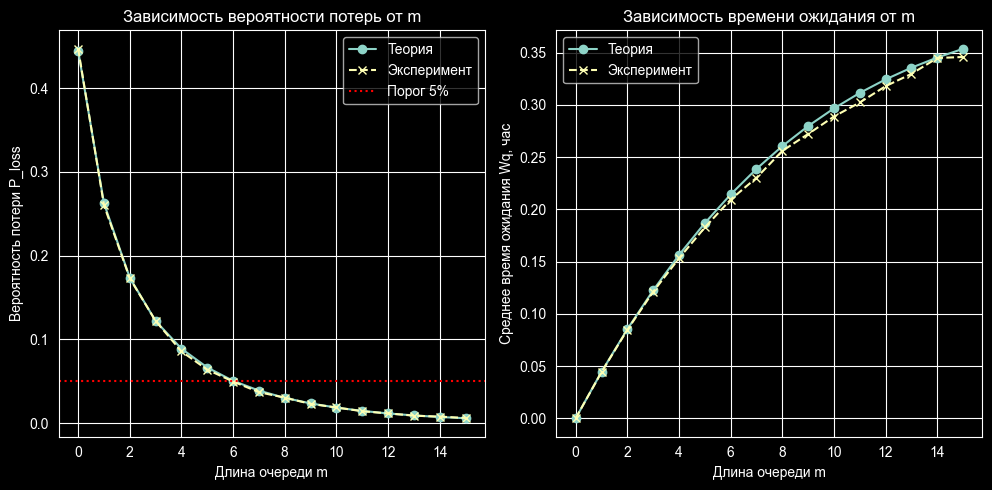

Оптимальная длина очереди m = 6 (вероятность потерь ≤ 5%)


In [12]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

def run_simulation(lambda_rate, mu_rate, m, sim_time, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    env = simpy.Environment()
    stats = Stats()
    doctor = Doctor(env, stats, mu_rate, channels=1)
    max_system_size = m + 1
    generator = PatientStreamGenerator(env, stats, doctor, lambda_rate, max_system_size)

    env.process(generator.start())
    env.run(until=sim_time)

    p_loss_exp = stats.lost / stats.arrived if stats.arrived > 0 else 0.0
    utilization = stats.busy_time / sim_time if sim_time > 0 else 0.0
    wq_exp = stats.total_wait_time / stats.served if stats.served > 0 else 0.0
    w_exp = np.mean(stats.system_times) if stats.system_times else 0.0
    lq_exp = stats.queue_area / sim_time

    return stats, {
        "P_loss": p_loss_exp,
        "utilization": utilization,
        "Wq": wq_exp,
        "Lq": lq_exp,
        "W": w_exp,
        "arrived": stats.arrived,
        "served": stats.served,
        "lost": stats.lost
    }

def theoretical_mm1m(lambda_rate, mu_rate, m, eps=1e-9):
    rho = lambda_rate / mu_rate
    K = m + 1

    if abs(rho - 1.0) < eps:
        P0 = 1.0 / (K + 1)
        P_loss = P0
        L = K / 2.0
    else:
        P0 = (1.0 - rho) / (1.0 - rho**(K + 1))
        P_loss = (rho**K) * P0
        L = rho / (1.0 - rho) - (K + 1) * (rho**(K + 1)) / (1.0 - rho**(K + 1))

    lambda_eff = lambda_rate * (1.0 - P_loss)
    Lq = L - (1.0 - P0)
    W = L / lambda_eff if lambda_eff > 0 else float('inf')
    Wq = Lq / lambda_eff if lambda_eff > 0 else float('inf')
    rho_eff = lambda_eff / mu_rate

    return {
        "P0": P0,
        "P_loss": P_loss,
        "L": L,
        "Lq": Lq,
        "W": W,
        "Wq": Wq,
        "rho_eff": rho_eff,
        "lambda_eff": lambda_eff
    }

def analyze_system(lambda_rate, mu_rate, m_values, sim_time, seed=42):
    th_P_loss = []
    th_Wq = []
    exp_P_loss = []
    exp_Wq = []

    print(f"{'m':>3} | {'P_loss теор':>11} | {'P_loss эксп':>11} | {'Wq теор':>8} | {'Wq эксп':>8}")

    for m in m_values:
        th = theoretical_mm1m(lambda_rate, mu_rate, m)
        _, exp = run_simulation(lambda_rate, mu_rate, m, sim_time, seed=seed)

        th_P_loss.append(th["P_loss"])
        th_Wq.append(th["Wq"])
        exp_P_loss.append(exp["P_loss"])
        exp_Wq.append(exp["Wq"])

        print(f"{m:3d} | {th['P_loss']:11.4f} | {exp['P_loss']:11.4f} | {th['Wq']:8.4f} | {exp['Wq']:8.4f}")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(m_values, th_P_loss, 'o-', label='Теория')
    plt.plot(m_values, exp_P_loss, 'x--', label='Эксперимент')
    plt.axhline(y=0.05, color='r', linestyle=':', label='Порог 5%')
    plt.xlabel('Длина очереди m')
    plt.ylabel('Вероятность потери P_loss')
    plt.title('Зависимость вероятности потерь от m')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(m_values, th_Wq, 'o-', label='Теория')
    plt.plot(m_values, exp_Wq, 'x--', label='Эксперимент')
    plt.xlabel('Длина очереди m')
    plt.ylabel('Среднее время ожидания Wq, час')
    plt.title('Зависимость времени ожидания от m')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    optimal_m = None
    for m, pl, epl in zip(m_values, th_P_loss, exp_P_loss):
        if (pl + epl) / 2 <= 0.05:
            optimal_m = m
            break
    if optimal_m is not None:
        print(f"Оптимальная длина очереди m = {optimal_m} (вероятность потерь ≤ 5%)")
    else:
        print("Среди рассмотренных m нет значения с P_loss ≤ 5%")

if __name__ == "__main__":
    LAMBDA = 8.0
    MU = 10.0
    BASE_M = 5
    SIM_TIME = 10000

    m_range = list(range(0, 16))

    print("Анализ системы M/M/1/m")
    print(f"λ = {LAMBDA} заявок/час, μ = {MU} заявок/час")
    print(f"Базовое m = {BASE_M}\n")

    th_base = theoretical_mm1m(LAMBDA, MU, BASE_M)
    _, exp_base = run_simulation(LAMBDA, MU, BASE_M, SIM_TIME, seed=42)

    print("Базовый вариант (m=5)")
    print(f"Теоретическая вероятность потери: {th_base['P_loss']:.4f}")
    print(f"Экспериментальная вероятность потери: {exp_base['P_loss']:.4f}")
    print(f"Среднее время ожидания (теор.): {th_base['Wq']:.4f} час")
    print(f"Среднее число заявок в очереди (теор.): {th_base['Lq']:.4f}")
    print(f"Коэффициент загрузки (теор.): {th_base['rho_eff']:.4f}\n")

    analyze_system(LAMBDA, MU, m_range, SIM_TIME, seed=42)